# **Классификация: превышает ли SI значение 8**

**Импортируем необходимые библиотеки**

In [1]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.3 MB/s eta 0:00:00


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.inspection import permutation_importance

from catboost import CatBoostClassifier

**Загружаем и подготавливаем данные**

In [13]:
df = pd.read_csv('https://raw.githubusercontent.com/nezhablack/project-on-drug-effictiveness/refs/heads/main/chemical_data.csv')
targets_to_exclude = [
    'IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log_SI',
    'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'
]

X = df.drop(columns = targets_to_exclude)
y = df['SI_above_8']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(f'Обучающая выборка: X = {X_train.shape}, y = {y_train.shape}')
print(f'Тестовая выборка:  X = {X_test.shape}, y = {y_test.shape}')
print(f'Доля положительного класса (Train): {y_train.mean():.2%}')
print(f'Доля положительного класса (Test): {y_test.mean():.2%}')

print(f'Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов')


Обучающая выборка: X = (800, 139), y = (800,)
Тестовая выборка:  X = (201, 139), y = (201,)
Доля положительного класса (Train): 35.62%
Доля положительного класса (Test): 35.82%
Датасет загружен: 1001 строк, 149 столбцов


**Визуализируем дисбаланс классов**

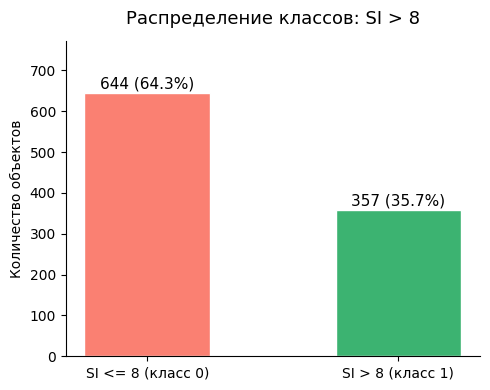

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = y.value_counts().sort_index()
colors = ['salmon', 'mediumseagreen']

bars = ax.bar(['SI <= 8 (класс 0)', 'SI > 8 (класс 1)'], counts.values, color = colors, edgecolor = 'white', width = 0.5)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, f'{val} ({val/len(y):.1%})', ha = 'center', va = 'bottom', fontsize = 11)

ax.set_title('Распределение классов: SI > 8', fontsize = 13, pad = 12)
ax.set_ylabel('Количество объектов')
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Вывод: если обучать модель на таких данных без коррекции, она будет предсказывать класс 0  чаще, получая высокую accuracy, но плохо находить класс 1. Это особенно критично, потому что именно класс 1 - показатель, который нужно обнаружить. Именно поэтому при разбивке на тренировочную и тестовую выборки использовали stratify = y, чтобы оба класса были представлены в каждом фолде равномерно.

**Обучаем модели и подбираем гиперпараметры**

In [ ]:
pipelines_clf = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(class_weight = 'balanced', random_state = 42, max_iter = 1000))
    ]),
    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(class_weight = 'balanced', probability = True, random_state = 42))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(class_weight = 'balanced', random_state = 42))
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', CatBoostClassifier(auto_class_weights = 'Balanced', random_seed = 42, verbose = 0))
    ])
}

param_grids_clf = {
    'LogisticRegression': {
        'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'model__penalty': ['l2']
    },
    'SVC': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    },
    'CatBoost': {
        'model__depth': [4, 6, 8],
        'model__iterations': [100, 300],
        'model__learning_rate': [0.05, 0.1],
        'model__l2_leaf_reg': [1, 3, 5]
    }
}

results_clf_si8 = []
best_models = {}

print('Запуск обучения моделей (SI > 8) с подбором параметров')

results_clf = []
best_clf_models = {}

print('Обучение классификаторов (GridSearchCV, cv=5)')

for name in pipelines_clf:
    print(f'{name}', end=' ')
    grid = GridSearchCV(pipelines_clf[name], param_grids_clf[name], cv = 5, scoring = 'f1', n_jobs = -1)
    grid.fit(X_train, y_train)
    best_clf_models[name] = grid.best_estimator_

    y_pred = grid.best_estimator_.predict(X_test)
    y_pred_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_pred_prob)

    results_clf.append({
        'Модель': name,
        'Лучшие гиперпараметры': str(grid.best_params_),
        'F1-score': round(f1, 4),
        'PR-AUC': round(pr_auc, 4),
        'Recall': round(rec, 4),
        'Precision': round(prec, 4),
        'Accuracy': round(acc, 4),
    })
    print(f'F1 = {f1:.4f}  PR-AUC = {pr_auc:.4f}  Recall = {rec:.4f}')

results_clf_df = (
    pd.DataFrame(results_clf)
    .sort_values('F1-score', ascending = False)
    .reset_index(drop = True)
)

print('Результаты классификации SI_above_8')
display(results_clf_df)

Запуск обучения моделей (SI > 8) с подбором параметров
Обучение классификаторов (GridSearchCV, cv=5)
LogisticRegression F1 = 0.5500  PR-AUC = 0.5117  Recall = 0.6111
SVC F1 = 0.5806  PR-AUC = 0.6294  Recall = 0.6250
RandomForest F1 = 0.5426  PR-AUC = 0.6943  Recall = 0.4861
CatBoost F1 = 0.6000  PR-AUC = 0.6752  Recall = 0.6250
Результаты классификации SI_above_8


,Модель,Лучшие гиперпараметры,F1-score,PR-AUC,Recall,Precision,Accuracy
0,CatBoost,"{'model__depth': 6, 'model__iterations': 100, ...",0.6000,0.6752,0.6250,0.5769,0.7015
1,SVC,"{'model__C': 10, 'model__kernel': 'rbf'}",0.5806,0.6294,0.6250,0.5422,0.6766
2,LogisticRegression,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.5500,0.5117,0.6111,0.5000,0.6418
3,RandomForest,"{'model__max_depth': 10, 'model__min_samples_s...",0.5426,0.6943,0.4861,0.6140,0.7065


Вывод: по результатам нет явного лидера по всем метрикам одновременно. CatBoost лидирует по F1 (0.6) и Accuracy (0.707), RandomForest - по PR-AUC (0.694) и Precision (0.614), SVC и CatBoost делят первое место по Recall (0.625). Разные модели оптимизируют разные аспекты качества.

В задаче поиска перспективных кандидатов пропуск активного соединения критичнее ложного отбора неэффективного, поэтому приоритетна метрика Recall. По этому критерию CatBoost и SVC равнозначны. Однако CatBoost при этом точнее, что делает его предпочтительным выбором.

RandomForest не подходит для скрининга. Несмотря на высокий Precision (0.614) и PR-AUC (0.694), Recall составил лишь 0.486 - модель пропускает каждый второй перспективный кандидат. При ограниченном числе соединений эта модель не подходит.

Logistic Regression уступает по всем метрикам. Это указывает на нелинейный характер зависимостей в данных, с которым линейная модель не справляется.

**Строим сравнительную диаграмму метрик**

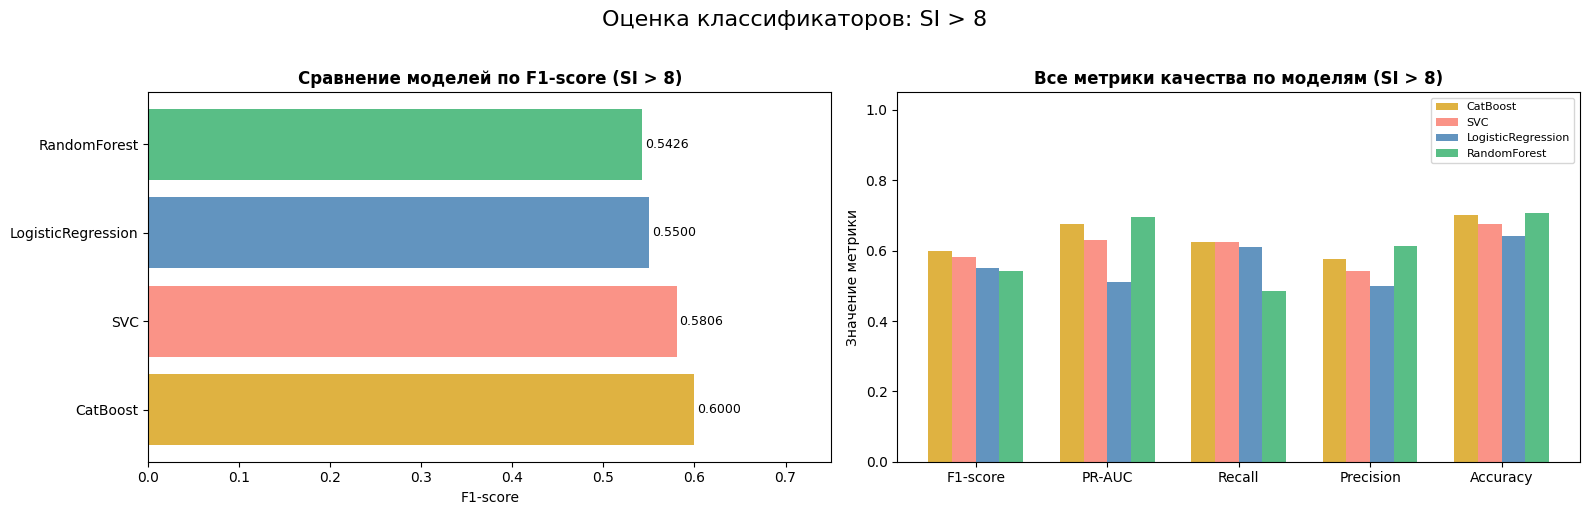

In [ ]:
model_colors = {
    'LogisticRegression': 'steelblue',
    'SVC': 'salmon',
    'RandomForest': 'mediumseagreen',
    'CatBoost': 'goldenrod',
}

metrics = ['F1-score', 'PR-AUC', 'Recall', 'Precision', 'Accuracy']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#строим графики по F1-score
bar_colors = [model_colors.get(m, 'gray') for m in results_clf_df['Модель']]
bars = axes[0].barh(results_clf_df['Модель'], results_clf_df['F1-score'], color=bar_colors, alpha=0.85)
axes[0].set_xlabel('F1-score')
axes[0].set_title('Сравнение моделей по F1-score (SI > 8)', fontweight='bold')
axes[0].set_xlim(0, max(results_clf_df['F1-score']) * 1.25)
for bar, val in zip(bars, results_clf_df['F1-score']):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                 f'{val:.4f}', va='center', fontsize=9)

#строим график всех метрик
x = np.arange(len(metrics))
n_models = len(results_clf_df)
width = 0.18
offsets = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width

for i, (_, row) in enumerate(results_clf_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1].bar(x + offsets[i], vals, width, label = row['Модель'], color = model_colors.get(row['Модель'], 'gray'), alpha = 0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Все метрики качества по моделям (SI > 8)', fontweight = 'bold')
axes[1].legend(fontsize = 8)
axes[1].set_ylabel('Значение метрики')

plt.suptitle('Оценка классификаторов: SI > 8', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

**Построим матрицы ошибок моделей**

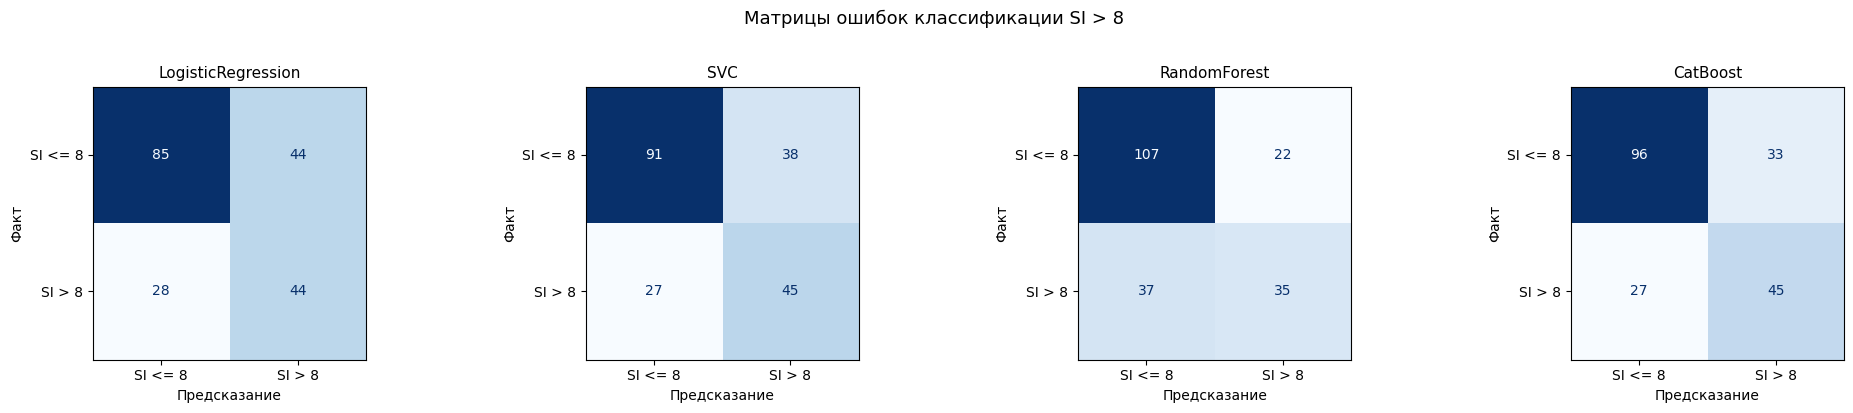

In [ ]:
fig, axes = plt.subplots(1, 4, figsize = (20, 4))

for ax, (name, model) in zip(axes, best_clf_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['SI <= 8', 'SI > 8'])
    disp.plot(ax = ax, colorbar = False, cmap = 'Blues')
    ax.set_title(f'{name}', fontsize = 11)
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Факт')

plt.suptitle('Матрицы ошибок классификации SI > 8', fontsize = 13, y = 1.02)
plt.tight_layout()
plt.show()

Вывод: на первичном этапе отбора перспективных кандидатов FN критичнее FP, потому что пропустить эффективное и безопасное соединение хуже, чем ошибочно отобрать плохое. По этому критерию SVC и CatBoost одинаково хороши (FN=27), но CatBoost дополнительно имеет меньше FP (33 против 38), что делает его предпочтительным выбором.

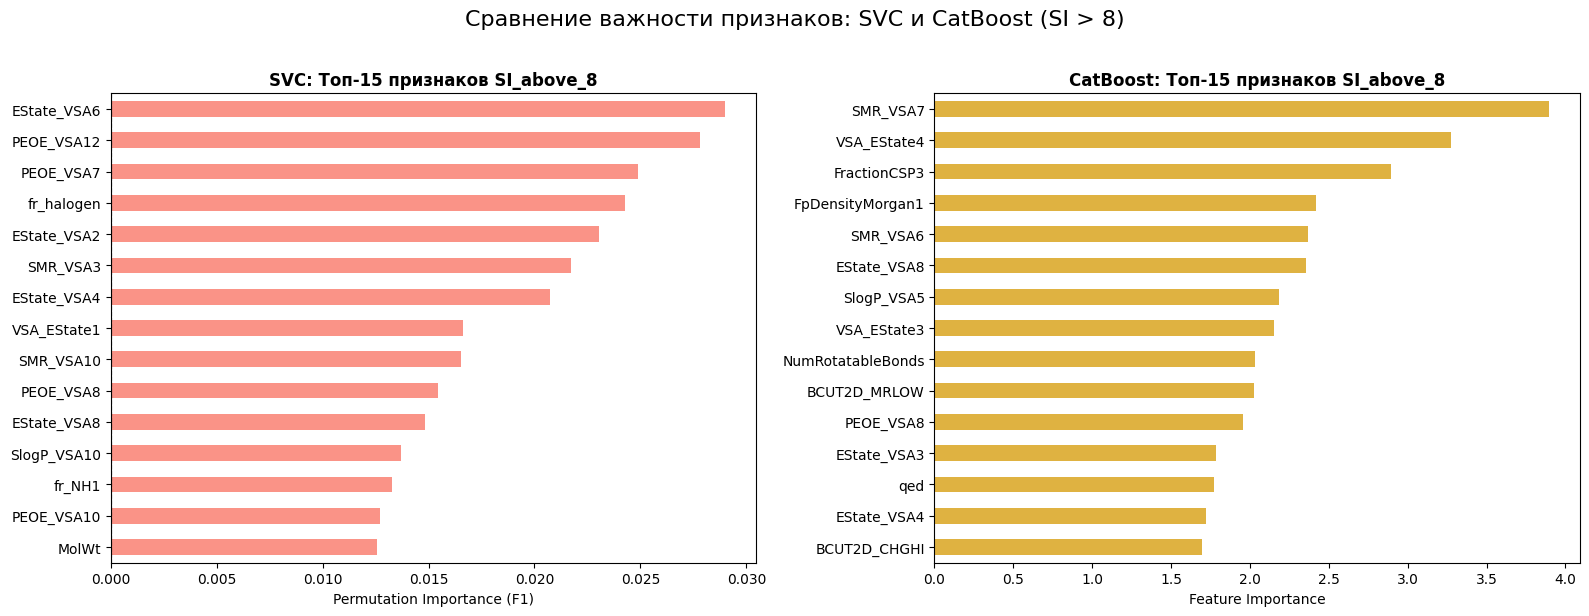

In [ ]:
#строим график важности признаков для CatBoost
cb_imp = (
    pd.Series(
        best_clf_models['CatBoost'].named_steps['model'].get_feature_importance(),
        index=X_train.columns
    )
    .sort_values(ascending=False)
    .head(15)
)

#строим график важности признаков для SVC
perm = permutation_importance(best_clf_models['SVC'], X_test, y_test, n_repeats = 10, random_state = 42, scoring = 'f1', n_jobs = -1)
svc_imp = (pd.Series(perm.importances_mean, index = X_train.columns).sort_values(ascending = False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

svc_imp[::-1].plot(kind='barh', ax = axes[0], color = 'salmon', alpha = 0.85)
axes[0].set_title('SVC: Топ-15 признаков SI_above_8', fontweight = 'bold')
axes[0].set_xlabel('Permutation Importance (F1)')
axes[0].axvline(0, color = 'black', lw=0.8, linestyle='--')

cb_imp[::-1].plot(kind = 'barh', ax = axes[1], color = 'goldenrod', alpha = 0.85)
axes[1].set_title('CatBoost: Топ-15 признаков SI_above_8', fontweight = 'bold')
axes[1].set_xlabel('Feature Importance')

plt.suptitle('Сравнение важности признаков: SVC и CatBoost (SI > 8)', fontsize = 16, y = 1.02)
plt.tight_layout()
plt.show()

Вывод: модели используют разные признаки. Они нашли разные информативные дескрипторы для классификации SI > 8, потому что строят решения разными способами.

В обоих топ-15 присутствуют EState_VSA4, EState_VSA8, PEOE_VSA8 и SMR_VSA - это наиболее устойчивые предикторы, независимо от алгоритма. Именно на них стоит сосредоточиться при дальнейшем отборе признаков.

У CatBoost лидерует признак SMR_VSA7 = 4. Он сильно выделяется на фоне остальных. Это говорит о том, что CatBoost опирается на несколько доминирующих признаков. Это может быть как плюсом, так и минусом. Модель интерпретируема, но если этот признак зашумлен или нерепрезентативен на новых данных, качество модели сильно упадет.

У SVC топ-15 признаков распределены более равномерно (от 0.012 до 0.03), значит SVC использует более широкий и равномерный набор. SVC более устойчив к шуму отдельных признаков. Это делает SVC менее чувствительным к выпадению или зашумлению конкретного признака, но также сложнее поддается химической интерпретации

**Финальные выводы и рекомендации**

Выводы: по совокупности метрик лучшей моделью является CatBoost (F1 = 0.6, PR-AUC = 0.675). Из 72 соединений с SI > 8 в тестовой выборке модель правильно идентифицировала 45, допустив 27 ложноотрицательных предсказаний. При этом CatBoost обеспечивает наилучший баланс между Precision (0.577) и Recall (0.625), что важно при дисбалансе классов.

SVC показывает аналогичный Recall (0.625) при более низком Precision (0.542) и F1 (0.581). Матрица ошибок подтверждает: из 72 истинных SI > 8 найдено также 45, однако число ложноположительных срабатываний выше (38 против 33 у CatBoost). Это означает, что SVC чаще ошибочно относит соединения с SI ≤ 8 в положительный класс.

RandomForest демонстрирует самый высокий Precision (0.614) и Accuracy (0.707), однако Recall составил лишь 0.486 - модель пропустила 37 из 72 перспективных кандидатов. В задаче поиска перспективных соединений такие потери критичны: пропуск активного кандидата обходится дороже, чем ложное определение.

Logistic Regression уступает по всем метрикам, что свидетельствует о нелинейном характере зависимостей в данных.

**Рекомендации:**
- дополнительно отобрать признаки, применить метод главных компонент для снижения размерности пространства признаков. При этом оставить совпадающие признаки из топ-15 обеих моделей (EState_VSA, SMR_VSA, PEOE_VSA), которые являются наиболее устойчивыми предикторами.
- собрать дополнительные данные. Это позволило бы моделям выявить более сложные закономерности и снизить переобучение.
- дополнительно поработать с дисбалансом классов. Примененная стратегия class_weight = 'balanced' частично компенсирует дисбаланс классов (36/64%), однако все метрики оценены на тестовой выборке из 201 объекта - это небольшой объем, при котором случайные флуктуации могут существенно влиять на значения F1 и Recall. Для более надежной оценки рекомендуется провести повторную cross-validation (например, RepeatedStratifiedKFold с 5 разбиениями и 10 повторами) на полном датасете без фиксированного отложенного теста.
- использовать стекинг моделей
